In [1]:
#Importing the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data = pd.read_csv('new_hampshire_real_estate_2026.csv')
data.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
0,single_family,NaN,Welcome to this spacious home offering endless...,565000,3520.0,3.0,4.0,3.0,1.0,2.0,2.0
1,single_family,NaN,Quintessential New Hampshire Living with Lake ...,449000,2203.0,2.0,3.0,2.0,2.0,2.0,2.0
2,single_family,NaN,Motivated Seller! Antique cape on three acres ...,209900,1350.0,NaN,2.0,1.0,1.0,1.0,NaN
3,single_family,NaN,"Meredith, NH 03253--You won't want to miss thi...",569000,3684.0,2.0,3.0,3.0,2.0,2.0,2.0
4,single_family,NaN,"Welcome to 10 Roy Drive, a true gem located in...",749000,3945.0,2.0,4.0,4.0,2.0,2.0,2.0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5009 entries, 0 to 5008
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             5009 non-null   object 
 1   sub_type         1060 non-null   object 
 2   text             4998 non-null   object 
 3   listPrice        5009 non-null   int64  
 4   sqft             3930 non-null   float64
 5   stories          3697 non-null   float64
 6   beds             3866 non-null   float64
 7   baths            3845 non-null   float64
 8   baths_full       3663 non-null   float64
 9   baths_full_calc  3838 non-null   float64
 10  garage           2448 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 430.6+ KB


In [4]:
data.isnull().sum()

type                  0
sub_type           3949
text                 11
listPrice             0
sqft               1079
stories            1312
beds               1143
baths              1164
baths_full         1346
baths_full_calc    1171
garage             2561
dtype: int64

In [5]:
data.describe()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
count,5.009000e+03,3930.000000,3697.000000,3866.000000,3845.000000,3663.000000,3838.000000,2448.000000
mean,6.192230e+05,2127.439440,1.810116,3.041904,2.450975,1.636910,1.990099,2.147467
std,7.369401e+05,1784.962713,0.694112,1.415239,1.220064,0.943674,1.042193,9.778791
min,4.500000e+02,240.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,2.500000e+05,1264.250000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000
50%,4.590000e+05,1789.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000
75%,7.149000e+05,2552.000000,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000
max,1.695000e+07,49502.000000,6.000000,27.000000,17.000000,12.000000,15.000000,480.000000


In [6]:
data.describe(include='O')

,type,sub_type,text
count,5009,1060,4998
unique,7,2,4812
top,single_family,condo,"Welcome to Our Town Village, a brand-new townh..."
freq,2293,657,18


# data desc insight
- Min 240 dollars has min of 450 sqrt with 1 story, baths full baths full calc garage respectively. but unfortunately no bathroom and beds
- max 49502 dollars has 1695000 sqft with 6 stories, 27 beds, 17 baths 12 baths full 15 baths full calc and 480 garages. these fascilies are provided at max rates

## EDA

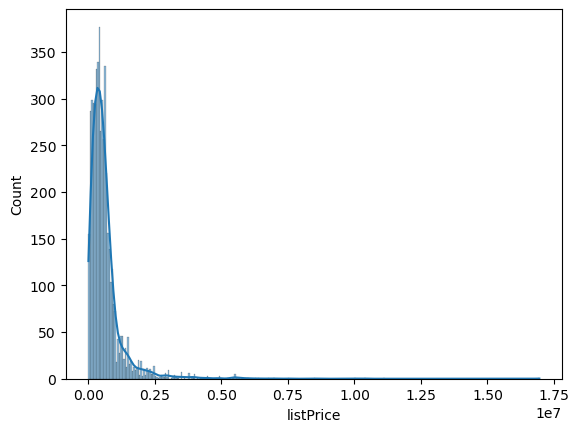

In [7]:
# univariate analysis

sns.histplot(data['listPrice'],kde=True)
plt.show()

# EDA Insight
- many people prefering low cost houses because of their economy conditions, and few richest person will prefer to purchase highcost houses. so they experiences luxurious life

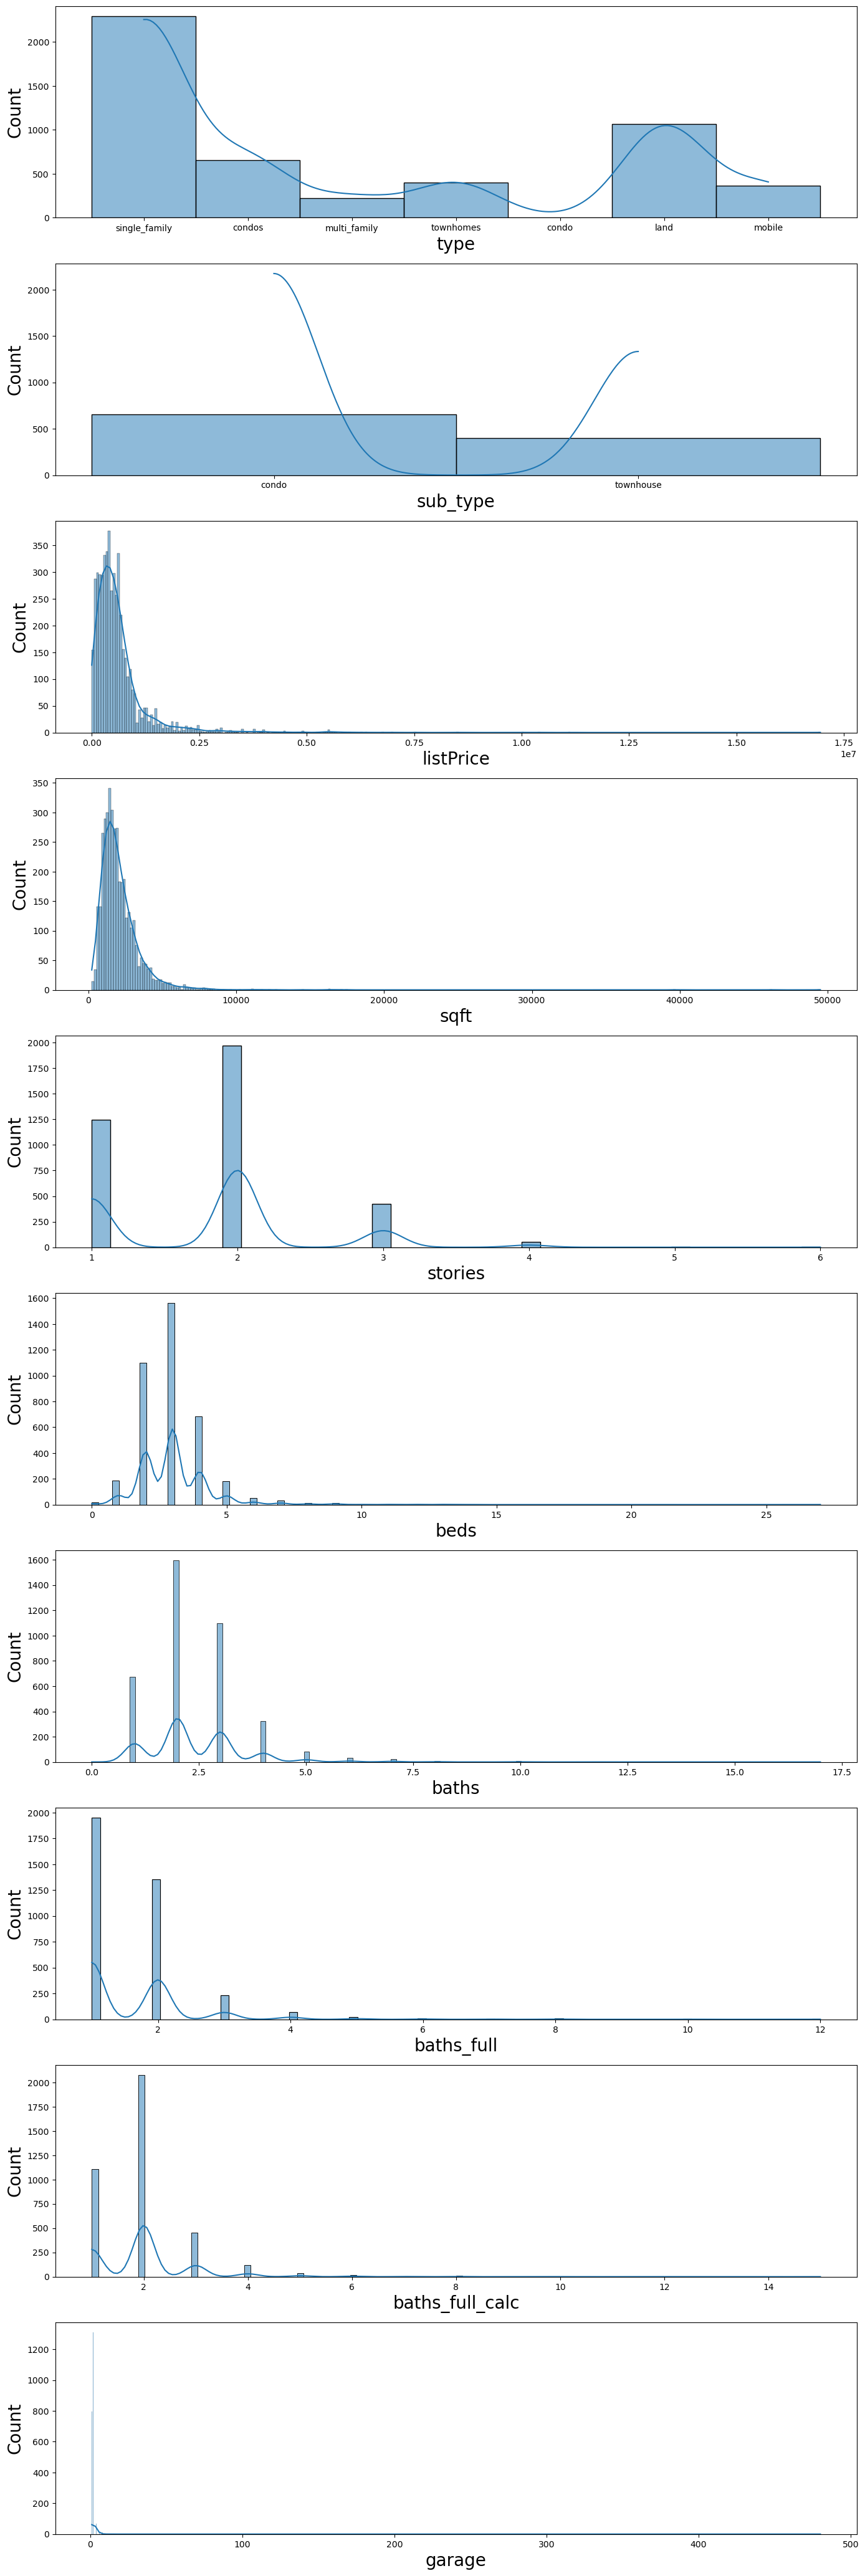

In [8]:
plot= 1
plt.figure(figsize=(14,45),facecolor='white',)
for col in data.drop('text',axis=1):
    if plot<=11:
        ax = plt.subplot(11,1,plot)
        sns.histplot(data[col],kde=True)
        plt.xlabel(col,fontsize=20)
        plt.ylabel("Count",fontsize=20)
    plot+=1
plt.tight_layout()
plt.show()


In [9]:
data.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
0,single_family,NaN,Welcome to this spacious home offering endless...,565000,3520.0,3.0,4.0,3.0,1.0,2.0,2.0
1,single_family,NaN,Quintessential New Hampshire Living with Lake ...,449000,2203.0,2.0,3.0,2.0,2.0,2.0,2.0
2,single_family,NaN,Motivated Seller! Antique cape on three acres ...,209900,1350.0,NaN,2.0,1.0,1.0,1.0,NaN
3,single_family,NaN,"Meredith, NH 03253--You won't want to miss thi...",569000,3684.0,2.0,3.0,3.0,2.0,2.0,2.0
4,single_family,NaN,"Welcome to 10 Roy Drive, a true gem located in...",749000,3945.0,2.0,4.0,4.0,2.0,2.0,2.0


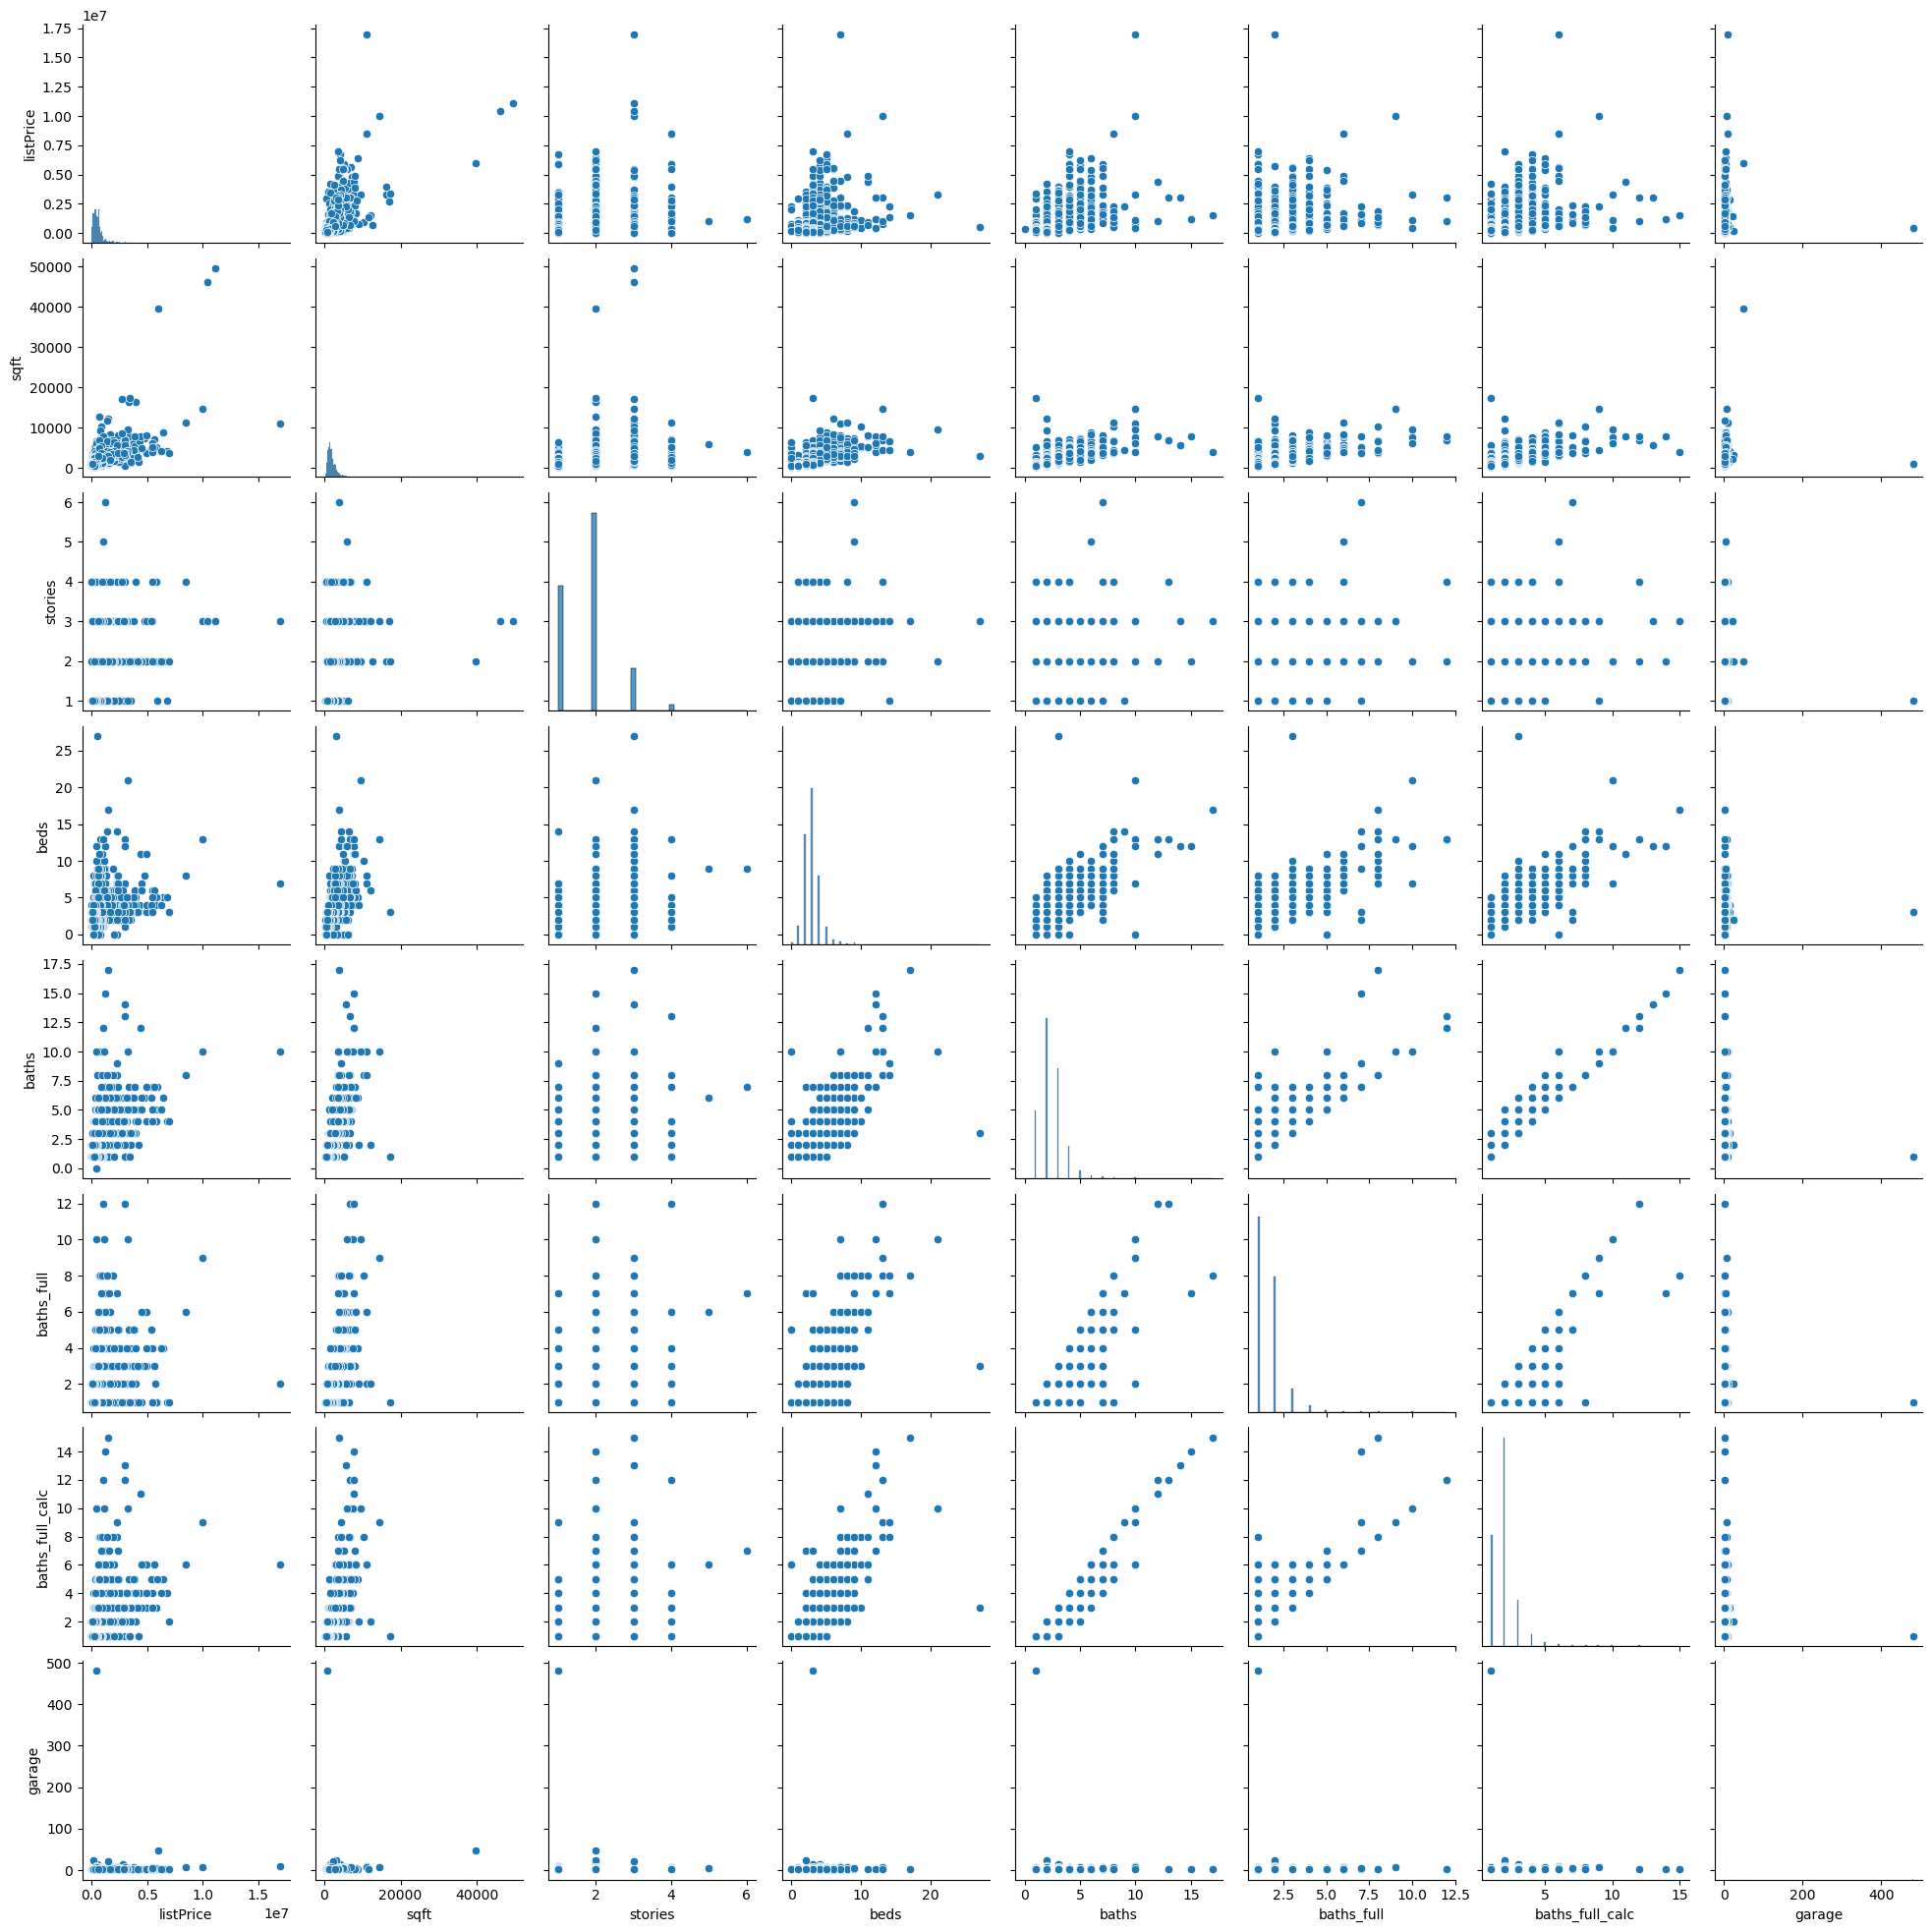

In [10]:
sns.pairplot(data.drop('text',axis=1))
plt.show()

In [11]:
data.columns

Index(['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds',
       'baths', 'baths_full', 'baths_full_calc', 'garage'],
      dtype='object')

In [13]:
data_numeric = data.select_dtypes(include=['float64','int64'])

<Figure size 1200x800 with 0 Axes>

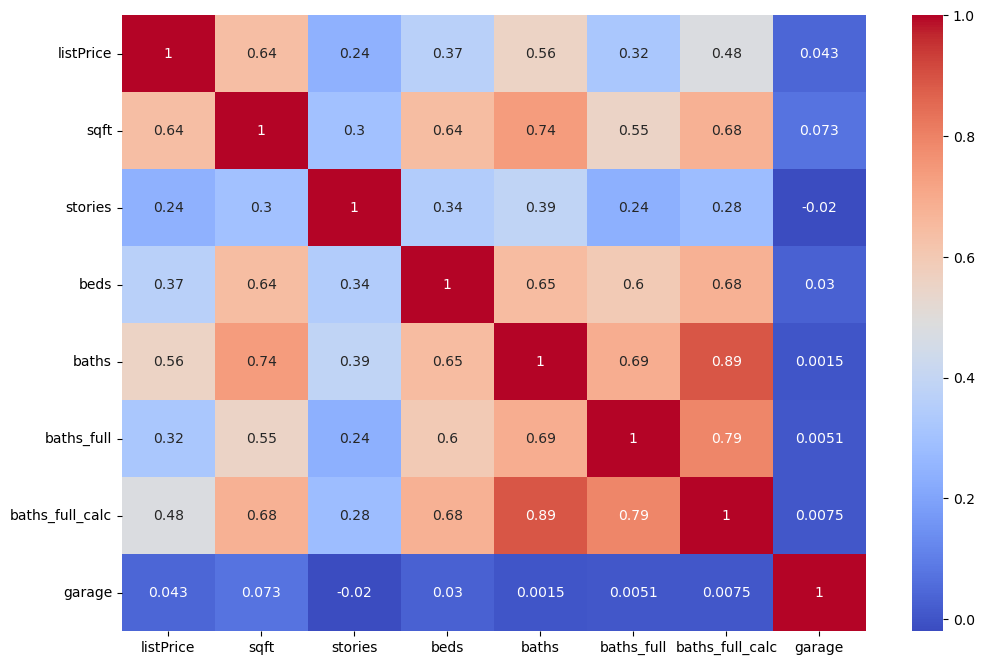

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(data_numeric.corr(),annot=True,cmap='coolwarm')
plt.show()

In [17]:
data_numeric.corr()


,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage
listPrice,1.000000,0.639970,0.240039,0.365093,0.557683,0.320888,0.481045,0.042587
sqft,0.639970,1.000000,0.297467,0.643388,0.738351,0.552662,0.679756,0.072790
stories,0.240039,0.297467,1.000000,0.343769,0.387132,0.235750,0.282052,-0.019668
beds,0.365093,0.643388,0.343769,1.000000,0.646997,0.596301,0.677997,0.030122
baths,0.557683,0.738351,0.387132,0.646997,1.000000,0.689896,0.891729,0.001506
baths_full,0.320888,0.552662,0.235750,0.596301,0.689896,1.000000,0.791311,0.005055
baths_full_calc,0.481045,0.679756,0.282052,0.677997,0.891729,0.791311,1.000000,0.007501
garage,0.042587,0.072790,-0.019668,0.030122,0.001506,0.005055,0.007501,1.000000


In [18]:
# baths_full_calc and baths datas are highly corelated. srop anyone column.
# from 2 columns, keep baths and drop baths_full_calc column. because it is less corelation with listPrice
data.drop('baths_full_calc',axis=1,inplace=True)

In [19]:
data.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,garage
0,single_family,NaN,Welcome to this spacious home offering endless...,565000,3520.0,3.0,4.0,3.0,1.0,2.0
1,single_family,NaN,Quintessential New Hampshire Living with Lake ...,449000,2203.0,2.0,3.0,2.0,2.0,2.0
2,single_family,NaN,Motivated Seller! Antique cape on three acres ...,209900,1350.0,NaN,2.0,1.0,1.0,NaN
3,single_family,NaN,"Meredith, NH 03253--You won't want to miss thi...",569000,3684.0,2.0,3.0,3.0,2.0,2.0
4,single_family,NaN,"Welcome to 10 Roy Drive, a true gem located in...",749000,3945.0,2.0,4.0,4.0,2.0,2.0


# data null imputations

In [20]:
data.isnull().sum()

type             0
sub_type      3949
text            11
listPrice        0
sqft          1079
stories       1312
beds          1143
baths         1164
baths_full    1346
garage        2561
dtype: int64

In [21]:
data['sub_type'].value_counts()

sub_type
condo        657
townhouse    403
Name: count, dtype: int64

In [23]:
(data.isnull().sum()/len(data))*100

type           0.000000
sub_type      78.838091
text           0.219605
listPrice      0.000000
sqft          21.541226
stories       26.192853
beds          22.818926
baths         23.238171
baths_full    26.871631
garage        51.127970
dtype: float64

In [24]:
# drop sub_type column because it has many nan values
data.drop('sub_type',axis=1,inplace=True)

In [25]:
data.head()

,type,text,listPrice,sqft,stories,beds,baths,baths_full,garage
0,single_family,Welcome to this spacious home offering endless...,565000,3520.0,3.0,4.0,3.0,1.0,2.0
1,single_family,Quintessential New Hampshire Living with Lake ...,449000,2203.0,2.0,3.0,2.0,2.0,2.0
2,single_family,Motivated Seller! Antique cape on three acres ...,209900,1350.0,NaN,2.0,1.0,1.0,NaN
3,single_family,"Meredith, NH 03253--You won't want to miss thi...",569000,3684.0,2.0,3.0,3.0,2.0,2.0
4,single_family,"Welcome to 10 Roy Drive, a true gem located in...",749000,3945.0,2.0,4.0,4.0,2.0,2.0


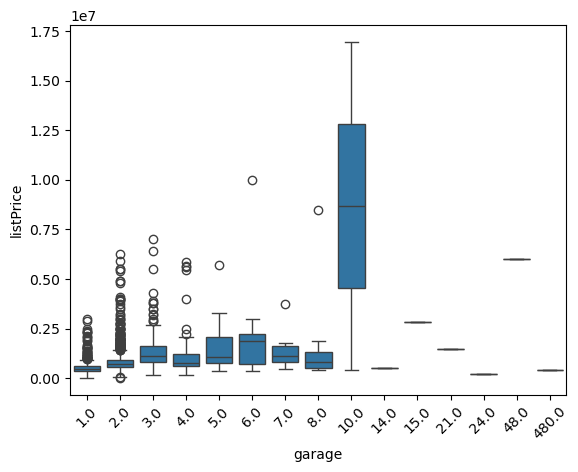

In [28]:
sns.boxplot(x='garage', y='listPrice', data=data)
plt.xticks(rotation=45)
plt.show()

In [27]:
data[['garage','listPrice']].corr()

,garage,listPrice
garage,1.000000,0.042587
listPrice,0.042587,1.000000


In [29]:
data['garage'] = data['garage'].clip(upper=4)

In [30]:
data[['garage','listPrice']].corr()

,garage,listPrice
garage,1.000000,0.369621
listPrice,0.369621,1.000000


In [34]:
data['garage'].isnull().sum()

0

In [33]:
data['garage'] = data['garage'].fillna(0)

In [35]:
data['garage'].value_counts()

garage
0.0    2561
2.0    1309
1.0     796
3.0     221
4.0     122
Name: count, dtype: int64

In [36]:
(data.isnull().sum()/len(data))*100

type           0.000000
text           0.219605
listPrice      0.000000
sqft          21.541226
stories       26.192853
beds          22.818926
baths         23.238171
baths_full    26.871631
garage         0.000000
dtype: float64

In [38]:
data['text'].isnull().sum()

11

In [39]:
data.drop('text',axis=1,inplace=True)

In [40]:
data.head()

,type,listPrice,sqft,stories,beds,baths,baths_full,garage
0,single_family,565000,3520.0,3.0,4.0,3.0,1.0,2.0
1,single_family,449000,2203.0,2.0,3.0,2.0,2.0,2.0
2,single_family,209900,1350.0,NaN,2.0,1.0,1.0,0.0
3,single_family,569000,3684.0,2.0,3.0,3.0,2.0,2.0
4,single_family,749000,3945.0,2.0,4.0,4.0,2.0,2.0


In [41]:
(data.isnull().sum()/len(data))*100

type           0.000000
listPrice      0.000000
sqft          21.541226
stories       26.192853
beds          22.818926
baths         23.238171
baths_full    26.871631
garage         0.000000
dtype: float64

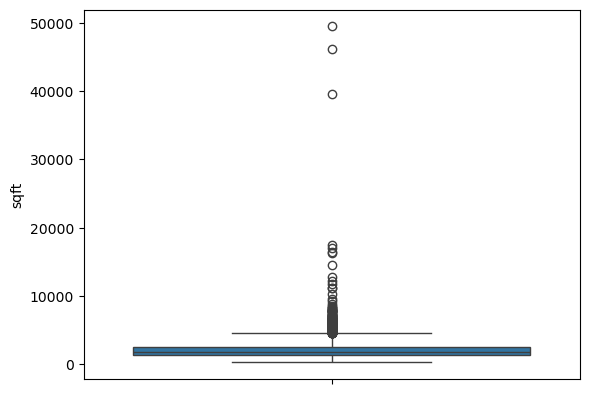

In [42]:
sns.boxplot(data['sqft'])
plt.show()

In [47]:
# Because high right skewness impute this col with median
data.loc[data['sqft'].isnull()==True,'sqft'] = data['sqft'].median()

In [48]:
data['stories'].value_counts()

stories
2.0    1971
1.0    1244
3.0     425
4.0      55
5.0       1
6.0       1
Name: count, dtype: int64

In [53]:
data.loc[data['stories'].isnull()==True,'stories'] = data['stories'].mode()[0]

In [54]:
data['beds'].value_counts()

beds
3.0     1563
2.0     1101
4.0      683
1.0      188
5.0      181
6.0       51
7.0       32
0.0       18
9.0       15
8.0       14
12.0       4
11.0       4
13.0       4
10.0       3
14.0       2
21.0       1
17.0       1
27.0       1
Name: count, dtype: int64

In [59]:
data.loc[data['beds'].isnull()==True,'beds'] = data['beds'].mode()[0]

In [60]:
data['baths'].value_counts()

baths
2.0     1595
3.0     1097
1.0      672
4.0      322
5.0       81
6.0       32
7.0       22
8.0       10
10.0       6
12.0       2
15.0       1
17.0       1
13.0       1
9.0        1
14.0       1
0.0        1
Name: count, dtype: int64

In [62]:
data.loc[data['baths'].isnull(),'baths'] = data['baths'].mode()[0]

In [63]:
data['baths_full'].value_counts()

baths_full
1.0     1950
2.0     1353
3.0      236
4.0       70
5.0       22
6.0       11
8.0        8
7.0        7
10.0       3
12.0       2
9.0        1
Name: count, dtype: int64

In [64]:
data.loc[data['baths_full'].isnull(),'baths_full'] = data['baths_full'].mode()[0]

In [65]:
data.isnull().sum()

type          0
listPrice     0
sqft          0
stories       0
beds          0
baths         0
baths_full    0
garage        0
dtype: int64

In [69]:
data.head()

,type,listPrice,sqft,stories,beds,baths,baths_full,garage
0,single_family,565000,3520.0,3.0,4.0,3.0,1.0,2.0
1,single_family,449000,2203.0,2.0,3.0,2.0,2.0,2.0
2,single_family,209900,1350.0,2.0,2.0,1.0,1.0,0.0
3,single_family,569000,3684.0,2.0,3.0,3.0,2.0,2.0
4,single_family,749000,3945.0,2.0,4.0,4.0,2.0,2.0


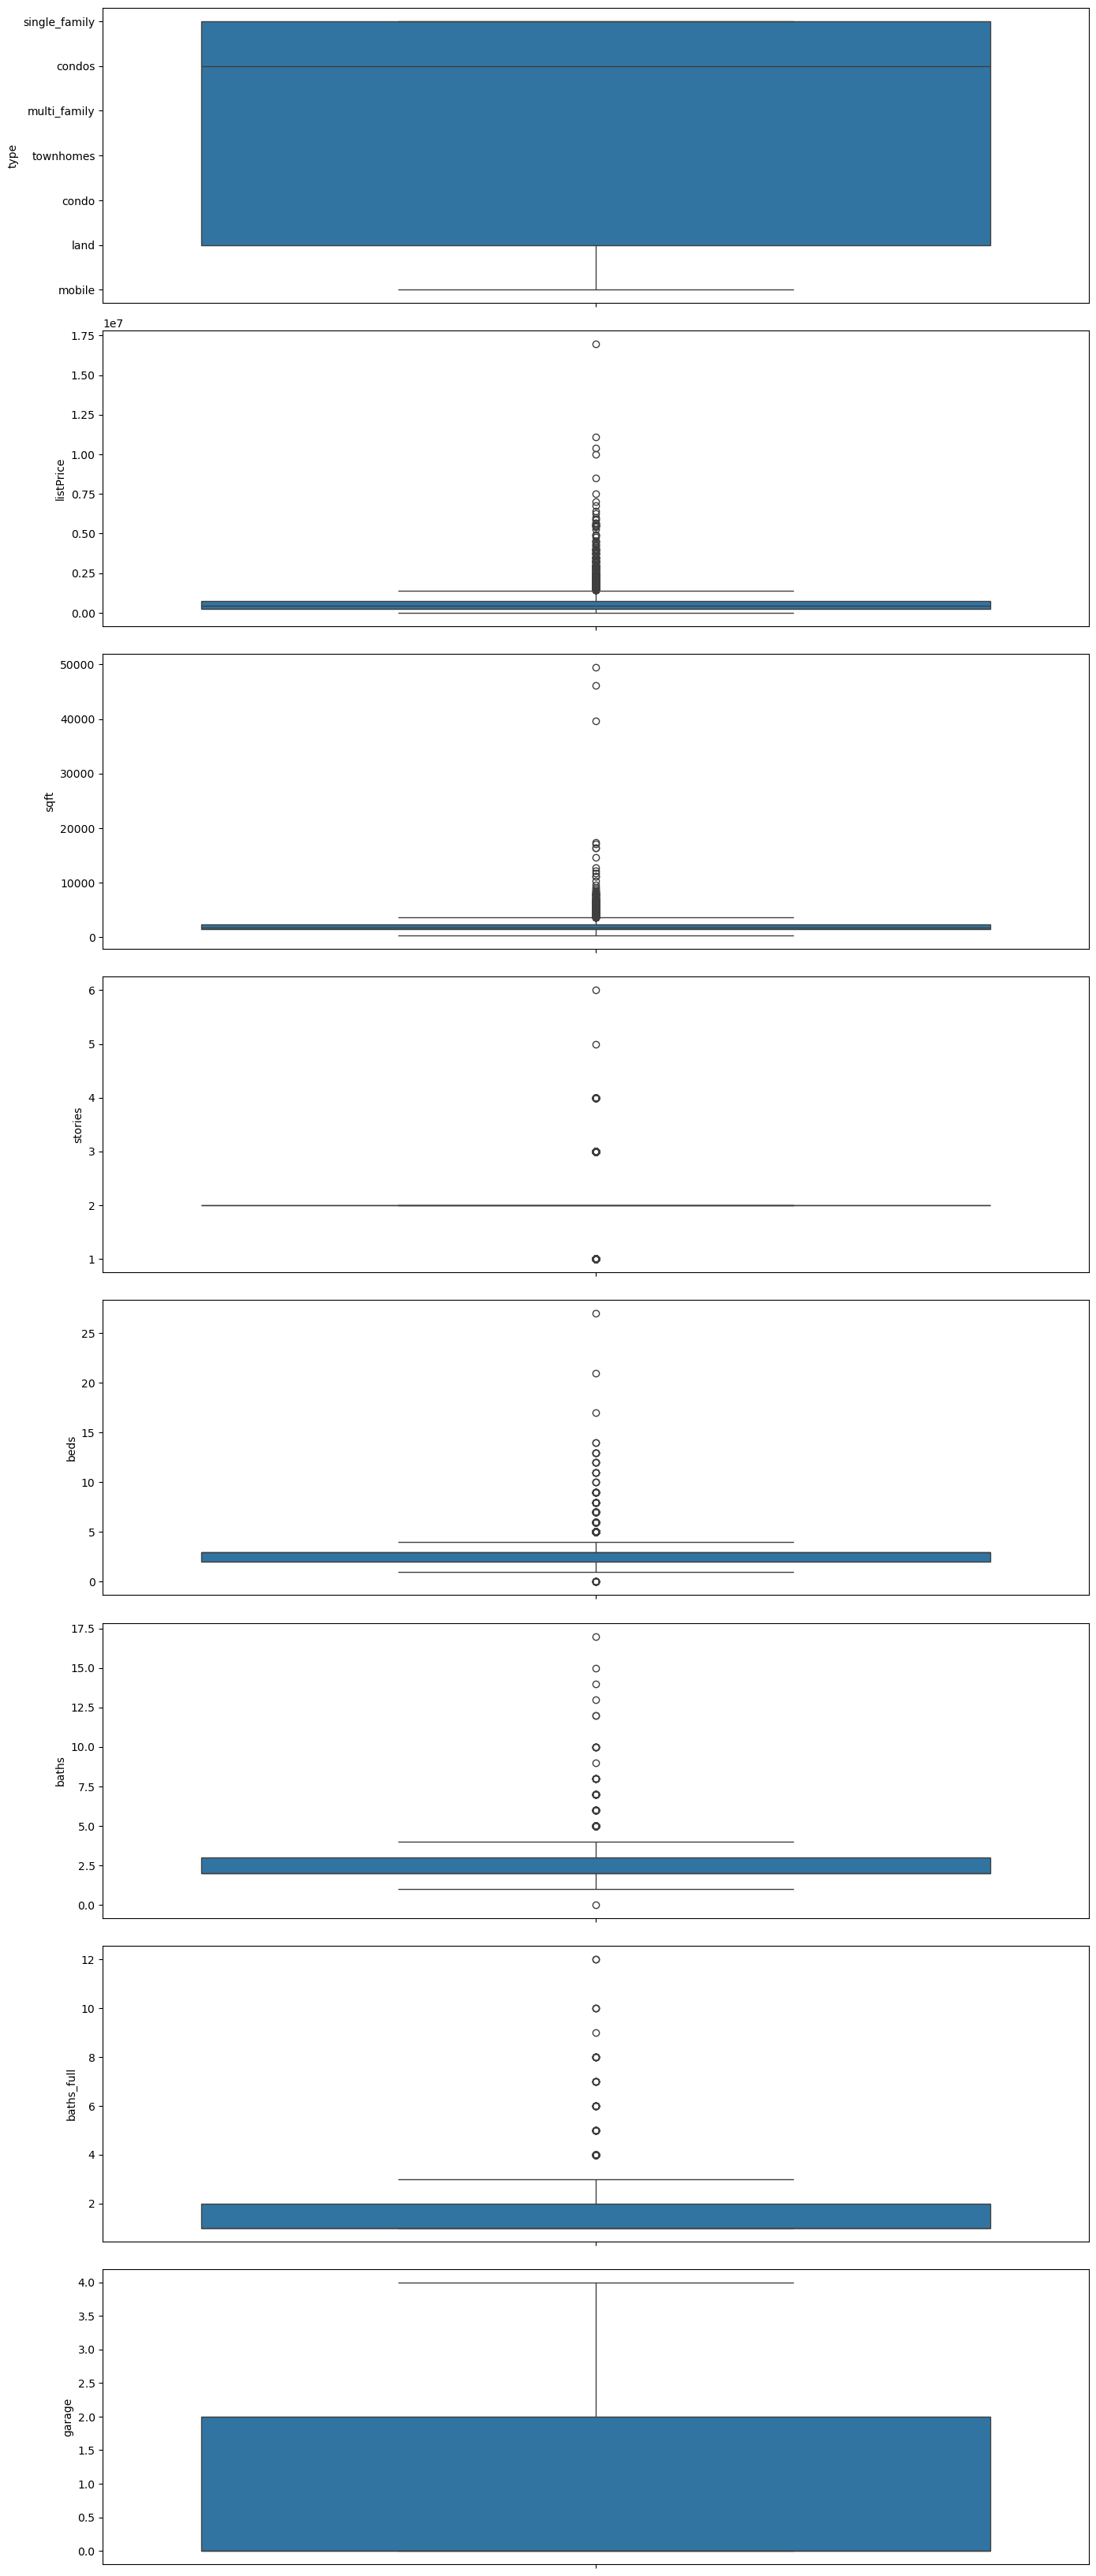

In [68]:
plot= 1
plt.figure(figsize=(14,45),facecolor='white',)
for col in data.columns:
    if plot<=11:
        ax = plt.subplot(11,1,plot)
        sns.boxplot(data[col])
        # plt.xlabel(col,fontsize=20)
        # plt.ylabel("Count",fontsize=20)
    plot+=1
plt.tight_layout()
plt.show()

In [71]:
# Both sqft and listPrice has right skewed and outliered. so apply log transform
data['sqft'] = np.log1p(data['sqft'])

In [72]:
data['listPrice'] = np.log1p(data['listPrice'])

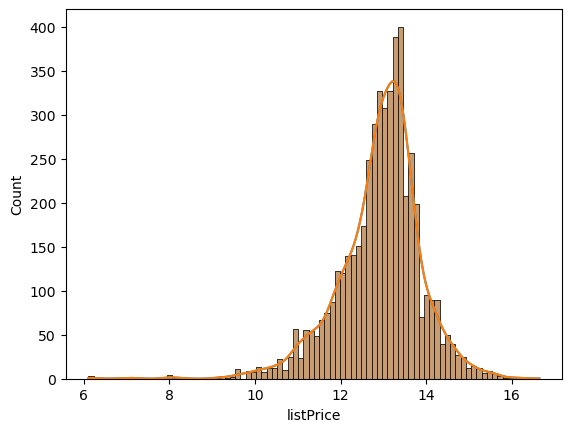

In [74]:
sns.histplot(data['listPrice'],kde=True)
plt.show()

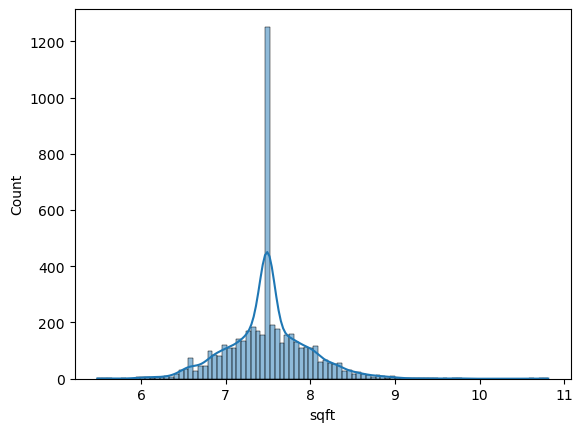

In [75]:
sns.histplot(data['sqft'],kde=True)
plt.show()

In [76]:
data.head()

,type,listPrice,sqft,stories,beds,baths,baths_full,garage
0,single_family,13.244583,8.166500,3.0,4.0,3.0,1.0,2.0
1,single_family,13.014780,7.698029,2.0,3.0,2.0,2.0,2.0
2,single_family,12.254391,7.208600,2.0,2.0,1.0,1.0,0.0
3,single_family,13.251637,8.212026,2.0,3.0,3.0,2.0,2.0
4,single_family,13.526496,8.280458,2.0,4.0,4.0,2.0,2.0


In [77]:
data['garage'].value_counts()

garage
0.0    2561
2.0    1309
1.0     796
3.0     221
4.0     122
Name: count, dtype: int64

In [78]:
data['type'].value_counts()

type
single_family    2293
land             1063
condos            657
townhomes         403
mobile            365
multi_family      224
condo               4
Name: count, dtype: int64

In [79]:
from sklearn.preprocessing import OneHotEncoder

data = pd.get_dummies(data, columns = ['type'],dtype='int',drop_first=True,prefix='type')

In [80]:
data.head()

,listPrice,sqft,stories,beds,baths,baths_full,garage,type_condos,type_land,type_mobile,type_multi_family,type_single_family,type_townhomes
0,13.244583,8.166500,3.0,4.0,3.0,1.0,2.0,0,0,0,0,1,0
1,13.014780,7.698029,2.0,3.0,2.0,2.0,2.0,0,0,0,0,1,0
2,12.254391,7.208600,2.0,2.0,1.0,1.0,0.0,0,0,0,0,1,0
3,13.251637,8.212026,2.0,3.0,3.0,2.0,2.0,0,0,0,0,1,0
4,13.526496,8.280458,2.0,4.0,4.0,2.0,2.0,0,0,0,0,1,0


## Modelling


In [81]:
X = data.drop('listPrice',axis=1)
y = data.listPrice

In [82]:
X.head()



,sqft,stories,beds,baths,baths_full,garage,type_condos,type_land,type_mobile,type_multi_family,type_single_family,type_townhomes
0,8.166500,3.0,4.0,3.0,1.0,2.0,0,0,0,0,1,0
1,7.698029,2.0,3.0,2.0,2.0,2.0,0,0,0,0,1,0
2,7.208600,2.0,2.0,1.0,1.0,0.0,0,0,0,0,1,0
3,8.212026,2.0,3.0,3.0,2.0,2.0,0,0,0,0,1,0
4,8.280458,2.0,4.0,4.0,2.0,2.0,0,0,0,0,1,0


In [83]:
y.head()

0    13.244583
1    13.014780
2    12.254391
3    13.251637
4    13.526496
Name: listPrice, dtype: float64

In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [85]:
Std = StandardScaler()
X_train = Std.fit_transform(X_train)
X_test = Std.transform(X_test)

In [86]:
X_test

array([[-0.02784378,  0.20899228, -0.02790308, ..., -0.21638563,
        -0.9191266 , -0.30151134],
       [ 0.06274891,  0.20899228, -0.02790308, ..., -0.21638563,
         1.0879894 , -0.30151134],
       [-0.02784378,  0.20899228, -0.02790308, ..., -0.21638563,
        -0.9191266 , -0.30151134],
       ...,
       [ 0.94960744, -1.41958658, -0.02790308, ..., -0.21638563,
         1.0879894 , -0.30151134],
       [-0.38029957,  0.20899228, -0.8042287 , ..., -0.21638563,
        -0.9191266 ,  3.31662479],
       [-0.02784378,  0.20899228, -0.02790308, ..., -0.21638563,
        -0.9191266 , -0.30151134]])

In [87]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [88]:
y_pred = lr.predict(X_test)

In [90]:
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error,root_mean_squared_error

print(f"R2 Score: {r2_score(y_test,y_pred)}")
print(f"RMSE: {root_mean_squared_error(y_test,y_pred)}")
print(f"MSE: {mean_squared_error(y_test,y_pred)}")
print(f"MAE: {mean_absolute_error(y_test,y_pred)}")

R2 Score: 0.4823999378217281
RMSE: 0.7069252425955986
MSE: 0.49974329861884603
MAE: 0.45302714545035994
